In [1]:
# 1. Instalamos las librerías necesarias
!pip install -q getdist emcee

import numpy as np
import pandas as pd
import scipy.integrate as integrate
import matplotlib.pyplot as plt

print("Cargando los datos...")

# 2. Cargar el "CSV" engañoso con Pandas
nombres_columnas = ['PREFIX', 'CID', 'IDSURVEY', 'zHD', 'zHEL', 'MU', 'MUERR', 'MUERR_VPEC', 'MUERR_SYS', 'PROB1A_BEAMS']

df_des = pd.read_csv('DES-Dovekie_HD.csv',
                     sep=r'\s+',
                     comment='#',
                     names=nombres_columnas
                    )

# Forzamos que las columnas sean números decimales (floats)
df_des['zHD'] = pd.to_numeric(df_des['zHD'], errors='coerce')
df_des['MU'] = pd.to_numeric(df_des['MU'], errors='coerce')

# Borramos las filas vacías
df_des = df_des.dropna(subset=['zHD', 'MU'])

z_obs = df_des['zHD'].values.astype(float)
mu_obs = df_des['MU'].values.astype(float)

# 3. Cargar la Matriz de Covarianza Inversa (.npz)
archivo_npz = np.load('STAT+SYS.npz')

nsn = int(np.squeeze(archivo_npz['nsn']))
inv_cov_cruda = archivo_npz['cov']

# --- EL DESENROLLADOR DEL TRIÁNGULO ---
# Verificamos si el tamaño coincide exactamente con el triángulo superior N*(N+1)/2
if len(inv_cov_cruda.shape) == 1 and len(inv_cov_cruda) == (nsn * (nsn + 1)) // 2:
    print(f"La matriz vino comprimida en triángulo. Reconstruyendo a {nsn}x{nsn}...")

    # 1. Creamos una matriz vacía de NxN
    inv_cov = np.zeros((nsn, nsn))

    # 2. Obtenemos las coordenadas (i, j) del triángulo superior
    i_upper, j_upper = np.triu_indices(nsn)

    # 3. Llenamos el triángulo superior con los datos crudos
    inv_cov[i_upper, j_upper] = inv_cov_cruda

    # 4. Hacemos que sea simétrica copiando lo de arriba hacia abajo
    i_lower, j_lower = np.tril_indices(nsn, -1)
    inv_cov[i_lower, j_lower] = inv_cov.T[i_lower, j_lower]

else:
    # Por si acaso la descargaste en otro formato que ya venía en 2D
    inv_cov = inv_cov_cruda.reshape((nsn, nsn))


print(f"\n¡Éxito! Se cargaron {len(z_obs)} supernovas perfectamente numéricas.")
print(f"Tamaño real de la matriz de covarianza inversa: {inv_cov.shape}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 836.0/836.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.0 MB/s eta 0:00:00
Cargando los datos...
La matriz vino comprimida en triángulo. Reconstruyendo a 1820x1820...

¡Éxito! Se cargaron 1820 supernovas perfectamente numéricas.
Tamaño real de la matriz de covarianza inversa: (1820, 1820)


In [2]:
import emcee

# ---------------------------------------------------------
# 1. EL MODELO FÍSICO (Universo Flat Lambda-CDM)
# ---------------------------------------------------------

mB_obs = mu_obs + (-19.36) #****
def E_z(z, Om):
    return np.sqrt(Om * (1 + z)**3 + (1 - Om))

def distancia_luminosidad(z_array, Om, H0):
    c = 299792.458 # km/s #Wikipedia
    ints = np.array([integrate.quad(lambda x: 1.0/E_z(x, Om), 0, zi)[0] for zi in z_array])
    return (c / H0) * (1 + z_array) * ints

# Ahora calculamos la magnitud aparente teórica usando M_abs directamente
def mB_teoria(z_array, Om, H0, M_abs):
    D_L = distancia_luminosidad(z_array, Om, H0)
    return 5 * np.log10(D_L * 1e5) + M_abs

# ---------------------------------------------------------
# 2. LA FUNCIÓN LIKELIHOOD
# ---------------------------------------------------------

def log_likelihood(theta, z, mB_obs_data, inv_cov):
    Om, H0, M_abs = theta
    mB_th = mB_teoria(z, Om, H0, M_abs)
    delta = mB_obs_data - mB_th
    chi2 = np.dot(delta.T, np.dot(inv_cov, delta))
    return -0.5 * chi2
# ---------------------------------------------------------
# 3. LOS PRIORS (¡Aquí entra SH0ES!)
# ---------------------------------------------------------
def log_prior(theta):
    Om, H0, M_abs = theta

    if not (0.0 < Om < 1.0 and 50.0 < H0 < 100.0 and -21.0 < M_abs < -18.0):
        return -np.inf

    # M = -19.253 +- 0.027
    chi2_SH0ES_M = ((M_abs - (-19.253)) / 0.027)**2 #Riess et al. sección 5.0 pág 33 https://arxiv.org/pdf/2112.04510


    return -0.5 * chi2_SH0ES_M

def log_probability(theta, z, mB_obs_data, inv_cov):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mB_obs_data, inv_cov)

# ---------------------------------------------------------
# 4. EJECUTAR LA CADENA DE MARKOV (MCMC)
# ---------------------------------------------------------
n_walkers = 32 #duplicamos el valor que teníamos antes (16)
n_dim = 3  # [Omega_m, H0, M_abs]
n_steps = 3000 #duplicamos el valor que teníamos antes

# Iniciamos cerca de M = -19.25
pos_inicial = [0.33, 73.0, -19.25] + 1e-4 * np.random.randn(n_walkers, n_dim)

# Pasamos 'mB_obs' en lugar de 'mu_obs'
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability, args=(z_obs, mB_obs, inv_cov))

print(f"Iniciando MCMC de {n_steps} pasos...")
sampler.run_mcmc(pos_inicial, n_steps, progress=True)
print("¡Simulación completada!")

Iniciando MCMC de 3000 pasos...


100%|██████████| 3000/3000 [3:53:49<00:00,  4.68s/it]

¡Simulación completada!


Removed no burn in

--- Resultados Finales (DES + SH0ES) ---
H_0 = 73.32\pm 0.97
\Omega_m = 0.329\pm 0.016


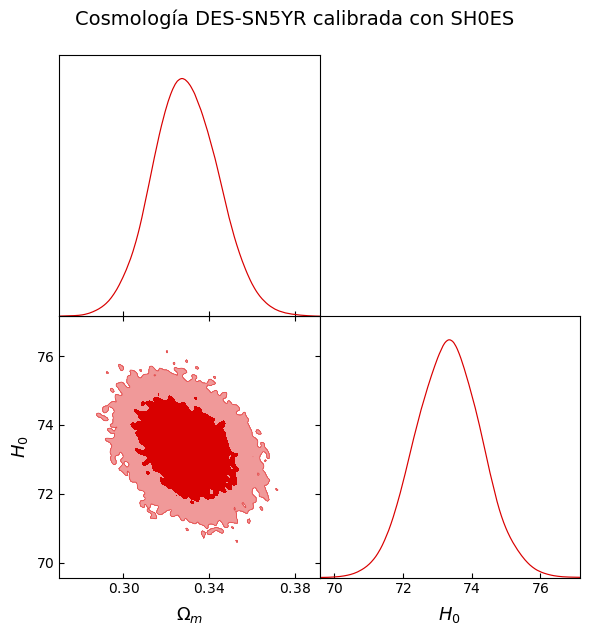


La tensión Q_DM frente a Planck es de: 5.41 sigmas


In [3]:
import getdist
from getdist import MCSamples, plots

# 1. Cortamos el primer 30% como "burn-in"
burn_in = int(0.3 * n_steps)
muestras_planas = sampler.get_chain(discard=burn_in, flat=True)

# 2. Pasamos los datos a GetDist (Columna 0 es Om, Columna 1 es H0)
muestras_para_getdist = np.column_stack((muestras_planas[:, 1], muestras_planas[:, 0]))

chain_des = MCSamples(samples=muestras_para_getdist,
                      names=['H0', 'omegam'],
                      labels=['H_0', r'\Omega_m'])

print("\n--- Resultados Finales (DES + SH0ES) ---")
print(chain_des.getInlineLatex('H0'))
print(chain_des.getInlineLatex('omegam'))

# 3. Graficar el resultado
g = plots.get_subplot_plotter(width_inch=6)
g.triangle_plot([chain_des], ['omegam', 'H0'],
                filled=True, contour_colors=["#D90000"])

plt.suptitle('Cosmología DES-SN5YR calibrada con SH0ES', fontsize=14, y=1.05)
plt.show()

# 4. Cálculo de tu métrica Q_DM frente a Planck (H0 = 67.4 +- 0.5)
H0_des_mean = chain_des.getMeans()[0]
H0_des_var = chain_des.getVars()[0]

Q_DM = ((H0_des_mean - 67.4)**2) / (H0_des_var + 0.5**2)
tension_sigmas = np.sqrt(Q_DM)

print(f"\nLa tensión Q_DM frente a Planck es de: {tension_sigmas:.2f} sigmas")

In [ ]:
# Guardamos la cadena en un archivo .txt separado por espacios
# 'header' añade los nombres de las variables en la primera línea
np.savetxt('cadena_des_shoes_v2.txt', muestras_planas,
           header='Om H0 M_offset', comments='')

print("¡Cadena guardada exitosamente como cadena_des_shoes.txt!")

# Para volver a cargarlo en el futuro:
# muestras_recuperadas = np.loadtxt('cadena_des_shoes.txt', skiprows=1)

In [5]:
import datetime

print("Preparando los datos y el encabezado...")

# 1. Extraemos el log-posterior (post) directamente del sampler
post_plano = sampler.get_log_prob(discard=burn_in, flat=True)

# 2. Recalculamos el log-prior para cada muestra usando tu función log_prior
# (Como son muchas muestras, esto puede tardar un par de segundos)
prior_plano = np.array([log_prior(theta) for theta in muestras_planas])

# 3. Unimos las 3 columnas de parámetros con las 2 de probabilidades
# El orden será: Om, H0, M_offset, prior, post
datos_completos = np.column_stack((muestras_planas, prior_plano, post_plano))

# 4. Construimos el encabezado personalizado
# Usamos f-strings para inyectar variables reales de tu simulación
fecha_actual = datetime.datetime.now().isoformat()
muestras_totales = len(muestras_planas)

encabezado_cosmosis = f"""cosmological_parameters--omega_m	cosmological_parameters--h0	supernova_params--m	prior	post
#sampler=emcee
#n_varied=3
#timestamp={fecha_actual}
#walkers={n_walkers}
#samples={muestras_totales}
#nsteps={n_steps}
## START_OF_PARAMS_INI
## [runtime]
## sampler = emcee
## likelihood_only = T
##
## [emcee]
## walkers = {n_walkers}
## samples = {muestras_totales}
## nsteps = {n_steps}
##
## [pipeline]
## modules = consistency camb pantheon
## likelihoods = pantheon
## END_OF_PARAMS_INI
## START_OF_VALUES_INI
## [cosmological_parameters]
## omega_m = 0.0  0.33  1.0
## h0 = 50.0  73.0  100.0
##
## [supernova_params]
## m = -5.0  0.0  5.0
## END_OF_VALUES_INI
## START_OF_PRIORS_INI
## [cosmological_parameters]
## h0 = gaussian 73.04 1.04
## END_OF_PRIORS_INI"""

# 5. Guardamos el archivo
# comments='' evita que NumPy ponga un '#' extra al principio del texto
np.savetxt('cadena_des_shoes_cosmosis.txt',
           datos_completos,
           delimiter='\t',
           header=encabezado_cosmosis,
           comments='')

print("¡Listo! Cadena guardada exitosamente como 'cadena_des_shoes_cosmosis.txt'")

Preparando los datos y el encabezado...
¡Listo! Cadena guardada exitosamente como 'cadena_des_shoes_cosmosis.txt'


#Consideramos Union 3

In [6]:
!pip install -q astropy getdist emcee

import numpy as np
import emcee
from astropy.io import fits
import datetime
import getdist
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

print("Cargando la matriz de Union3 desde el archivo FITS...")

# Leemos el archivo FITS (asegúrate de que esté subido a Colab)
archivo_fits = 'mu_mat_union3_cosmo=2_mu.fits'
hdul = fits.open(archivo_fits)
datos_fits = hdul[0].data

# La estructura de Rubin:
# Fila 0 (a partir de la columna 1) = redshift (z)
# Columna 0 (a partir de la fila 1) = módulo de distancia (mu)
# El bloque central = Matriz de covarianza inversa
z_obs_u3 = datos_fits[0, 1:]
mu_obs_u3 = datos_fits[1:, 0]
inv_cov_u3 = datos_fits[1:, 1:]

hdul.close()

print(f"¡Éxito! Se cargaron {len(z_obs_u3)} supernovas de Union3.")
print(f"Tamaño de la matriz de covarianza inversa: {inv_cov_u3.shape}")

Cargando la matriz de Union3 desde el archivo FITS...
¡Éxito! Se cargaron 22 supernovas de Union3.
Tamaño de la matriz de covarianza inversa: (22, 22)


In [13]:
# ---------------------------------------------------------
# MCMC PARA UNION3 (Desmarginalizado con Prior de SH0ES)
# ---------------------------------------------------------

# 1. PREPARACIÓN DE DATOS DE UNION3
# Reemplaza 'mu_obs_u3', 'z_obs_u3' e 'inv_cov_u3' por los nombres exactos de tus variables de Union3
# NOTA: Aplica aquí el valor de desempaquetado (M_fiducial) correspondiente a Union3

mB_obs_u3 = mu_obs_u3 + (-19.36)  # O el valor fiducial que corresponda a Union3 tras hacer la prueba

# 2. CONFIGURACIÓN DEL SAMPLER
n_walkers = 32
n_dim = 3      # [Omega_m, H0, M_abs]
n_steps = 3000

# Iniciamos los caminadores cerca del valor físico de SH0ES
pos_inicial_u3 = [0.33, 73.0, -19.25] + 1e-4 * np.random.randn(n_walkers, n_dim)

# 3. EJECUCIÓN (Pasamos las variables de Union3 en 'args')
sampler_u3 = emcee.EnsembleSampler(
    n_walkers,
    n_dim,
    log_probability, # Reutilizamos tu misma función genérica
    args=(z_obs_u3, mB_obs_u3, inv_cov_u3) # ¡Aquí inyectamos los datos de Union3!
)

print(f"Iniciando MCMC para Union3 de {n_steps} pasos...")
sampler_u3.run_mcmc(pos_inicial_u3, n_steps, progress=True)
print("¡Simulación de Union3 completada!")

# 4. EXTRACCIÓN DE CADENAS (Descartando el Burn-in)
# Esta es la variable 'muestras_planas_u3' que luego leerá GetDist
muestras_planas_u3 = sampler_u3.get_chain(discard=800, flat=True)

Iniciando MCMC para Union3 de 3000 pasos...


100%|██████████| 3000/3000 [02:06<00:00, 23.76it/s]

¡Simulación de Union3 completada!


Generando gráfico de contornos...
Removed no burn in

--- Resultados Union3 + SH0ES ---
H_0 = 76.0\pm 3.3
\Omega_m = 0.359^{+0.026}_{-0.029}


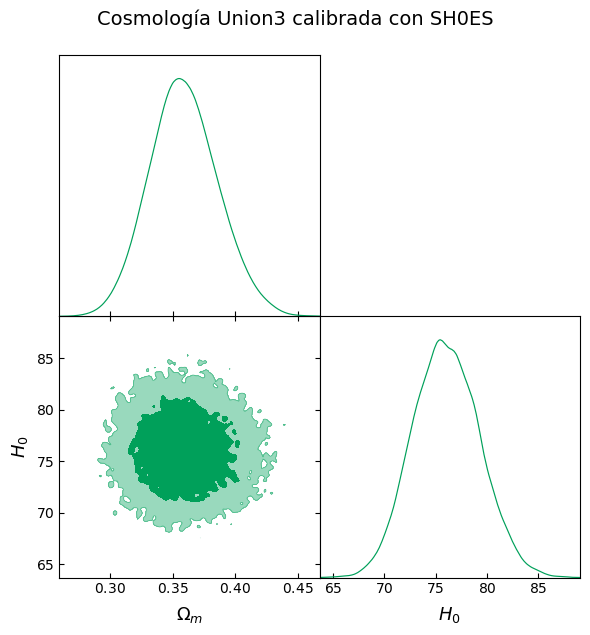

In [14]:
print("Generando gráfico de contornos...")

# Extraemos las columnas en el orden correcto para GetDist (H0, omegam)
col_omegam_u3 = muestras_planas_u3[:, 0]
col_H0_u3 = muestras_planas_u3[:, 1]
muestras_getdist_u3 = np.column_stack((col_H0_u3, col_omegam_u3))

# Creamos el objeto de muestras
chain_u3 = MCSamples(samples=muestras_getdist_u3,
                     names=['H0', 'omegam'],
                     labels=['H_0', r'\Omega_m'],
                     name_tag='Union3')

# Resultados rápidos en texto
print("\n--- Resultados Union3 + SH0ES ---")
print(chain_u3.getInlineLatex('H0'))
print(chain_u3.getInlineLatex('omegam'))

# Graficamos el triángulo
g = plots.get_subplot_plotter(width_inch=6)
g.triangle_plot([chain_u3], ['omegam', 'H0'],
                filled=True, contour_colors=["#00A05A"])

plt.suptitle('Cosmología Union3 calibrada con SH0ES', fontsize=14, y=1.05)
plt.show()

Generando gráfico de contornos...
Removed no burn in

--- Resultados Union3 + SH0ES ---
Omega_m:  \Omega_m = 0.359^{+0.026}_{-0.029}
H_0:      H_0 = 76.0\pm 3.3
M_abs:    M_{abs} = -19.253\pm 0.027


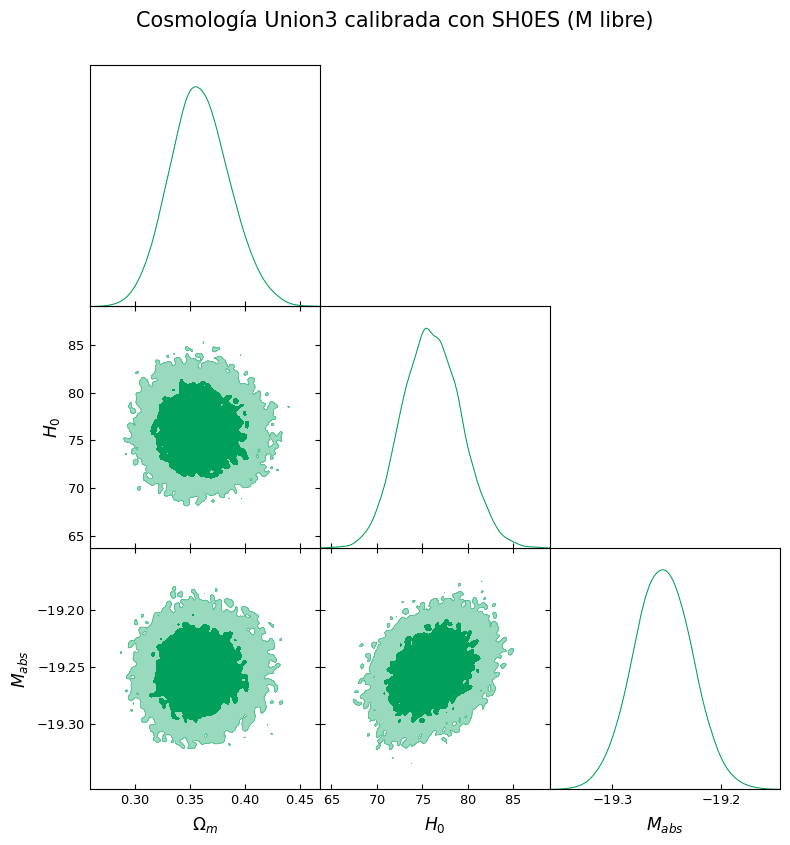

In [15]:
print("Generando gráfico de contornos...")

# 1. Extraemos las 3 columnas en el orden de nuestro MCMC
col_omegam_u3 = muestras_planas_u3[:, 0]
col_H0_u3 = muestras_planas_u3[:, 1]
col_Mabs_u3 = muestras_planas_u3[:, 2] # ¡Nuestra nueva dimensión desmarginalizada!

# Las apilamos en una matriz
muestras_getdist_u3 = np.column_stack((col_omegam_u3, col_H0_u3, col_Mabs_u3))

# 2. Creamos el objeto de muestras agregando M_abs
chain_u3 = MCSamples(samples=muestras_getdist_u3,
                     names=['omegam', 'H0', 'Mabs'],
                     labels=[r'\Omega_m', 'H_0', 'M_{abs}'],
                     name_tag='Union3')

# 3. Resultados rápidos en texto
print("\n--- Resultados Union3 + SH0ES ---")
print("Omega_m: ", chain_u3.getInlineLatex('omegam'))
print("H_0:     ", chain_u3.getInlineLatex('H0'))
print("M_abs:   ", chain_u3.getInlineLatex('Mabs'))

# 4. Graficamos el triángulo completo
g = plots.get_subplot_plotter(width_inch=8) # Más ancho para que respiren las 3 variables
g.triangle_plot([chain_u3], ['omegam', 'H0', 'Mabs'],
                filled=True, contour_colors=["#00A05A"])

plt.suptitle('Cosmología Union3 calibrada con SH0ES (M libre)', fontsize=15, y=1.05)
plt.show()

In [9]:
print("Guardando las cadenas...")

# ---------------------------------------------------------
# 1. GUARDAR COMO .TXT SIMPLE
# ---------------------------------------------------------
np.savetxt('cadena_union3_shoes.txt', muestras_planas_u3,
           header='Om H0 M_offset', comments='')
print("- Archivo 'cadena_union3_shoes.txt' generado.")

# ---------------------------------------------------------
# 2. GUARDAR COMO .TXT FORMATO COSMOSIS
# ---------------------------------------------------------
# Extraemos el posterior
post_plano_u3 = sampler_u3.get_log_prob(discard=burn_in, flat=True)

# Recalculamos el prior para cada muestra (puede tardar unos segundos)
prior_plano_u3 = np.array([log_prior(theta) for theta in muestras_planas_u3])

# Unimos todo: Om, H0, M_offset, prior, post
datos_cosmosis_u3 = np.column_stack((muestras_planas_u3, prior_plano_u3, post_plano_u3))

fecha_actual = datetime.datetime.now().isoformat()

encabezado_cosmosis_u3 = f"""cosmological_parameters--omega_m	cosmological_parameters--h0	supernova_params--m	prior	post
#sampler=emcee
#n_varied=3
#timestamp={fecha_actual}
#walkers={n_walkers}
#samples={muestras_totales_u3}
#nsteps={n_steps}
## START_OF_PARAMS_INI
## [runtime]
## sampler = emcee
## likelihood_only = T
##
## [emcee]
## walkers = {n_walkers}
## samples = {muestras_totales_u3}
## nsteps = {n_steps}
##
## [pipeline]
## modules = consistency camb pantheon
## likelihoods = pantheon
## END_OF_PARAMS_INI
## START_OF_VALUES_INI
## [cosmological_parameters]
## omega_m = 0.0  0.33  1.0
## h0 = 50.0  73.0  100.0
##
## [supernova_params]
## m = -5.0  0.0  5.0
## END_OF_VALUES_INI
## START_OF_PRIORS_INI
## [cosmological_parameters]
## h0 = gaussian 73.04 1.04
## END_OF_PRIORS_INI"""

np.savetxt('cadena_union3_shoes_cosmosis.txt',
           datos_cosmosis_u3,
           delimiter='\t',
           header=encabezado_cosmosis_u3,
           comments='')
print("- Archivo 'cadena_union3_shoes_cosmosis.txt' generado.")

Guardando las cadenas...
- Archivo 'cadena_union3_shoes.txt' generado.
- Archivo 'cadena_union3_shoes_cosmosis.txt' generado.


#Vamos a generar las mismas cadenas de antes pero cambiando el prior de H_0. En lugar de ~  73, a 67 [1/s]

In [10]:
import emcee
import getdist
from getdist import MCSamples, plots
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. EL MODELO FÍSICO Y LIKELIHOOD (DES)
# ---------------------------------------------------------
def E_z(z, Om):
    return np.sqrt(Om * (1 + z)**3 + (1 - Om))

def distancia_luminosidad(z_array, Om, H0):
    c = 299792.458
    ints = np.array([integrate.quad(lambda x: 1.0/E_z(x, Om), 0, zi)[0] for zi in z_array])
    return (c / H0) * (1 + z_array) * ints

def mu_teoria(z_array, Om, H0, M_offset):
    D_L = distancia_luminosidad(z_array, Om, H0)
    return 5 * np.log10(D_L * 1e5) + M_offset

def log_likelihood(theta, z, mu_obs, inv_cov):
    Om, H0, M_offset = theta
    mu_th = mu_teoria(z, Om, H0, M_offset)
    delta_mu = mu_obs - mu_th
    return -0.5 * np.dot(delta_mu.T, np.dot(inv_cov, delta_mu))

# ---------------------------------------------------------
# 2. EL NUEVO PRIOR (¡AQUÍ ENTRA PLANCK!)
# ---------------------------------------------------------
def log_prior_planck(theta):
    Om, H0, M_offset = theta
    if not (0.0 < Om < 1.0 and 50.0 < H0 < 100.0 and -5.0 < M_offset < 5.0):
        return -np.inf

    chi2_Planck = ((H0 - 67.4) / 0.5)**2
    return -0.5 * chi2_Planck

def log_prob_planck(theta, z, mu_obs, inv_cov):
    lp = log_prior_planck(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu_obs, inv_cov)

# ---------------------------------------------------------
# 3. EJECUTAR EL MCMC (DES + PLANCK)
# ---------------------------------------------------------
n_walkers, n_dim, n_steps = 16, 3, 1500
pos_inicial = [0.33, 67.4, 0.0] + 1e-4 * np.random.randn(n_walkers, n_dim)

print("Iniciando MCMC para DES con prior de PLANCK...")
sampler_des_planck = emcee.EnsembleSampler(n_walkers, n_dim, log_prob_planck, args=(z_obs, mu_obs, inv_cov))
sampler_des_planck.run_mcmc(pos_inicial, n_steps, progress=True)

# ---------------------------------------------------------
# 4. EXTRACCIÓN Y GUARDADO EN ARCHIVO TEXTO (.TXT)
# ---------------------------------------------------------
muestras_des_p = sampler_des_planck.get_chain(discard=int(0.3*n_steps), flat=True)

# Definimos el encabezado para que sepas qué es cada columna al abrir el bloc de notas
encabezado_des = "Omega_m\tH0\tM_offset"

np.savetxt('cadena_des_planck.txt',
           muestras_des_p,
           delimiter='\t',
           header=encabezado_des,
           comments='')

print("- Archivo 'cadena_des_planck.txt' generado y guardado exitosamente.")

# ---------------------------------------------------------
# 5. ANÁLISIS CON GETDIST Y GRÁFICO
# ---------------------------------------------------------
muestras_gd_des_p = np.column_stack((muestras_des_p[:, 1], muestras_des_p[:, 0]))
chain_des_p = MCSamples(samples=muestras_gd_des_p, names=['H0', 'omegam'], labels=['H_0', r'\Omega_m'])

print("\n--- Resultados Finales (DES + PLANCK) ---")
print(chain_des_p.getInlineLatex('H0'))
print(chain_des_p.getInlineLatex('omegam'))

g = plots.get_subplot_plotter(width_inch=6)
g.triangle_plot([chain_des_p], ['omegam', 'H0'], filled=True, contour_colors=["#0055A4"])
plt.suptitle('Cosmología DES-SN5YR calibrada con PLANCK', fontsize=14, y=1.05)
plt.show()

# Cálculo de Tensión inversa (Contra SH0ES: 73.04 +- 1.04)
H0_mean, H0_var = chain_des_p.getMeans()[0], chain_des_p.getVars()[0]
tension_sigmas = np.sqrt(((H0_mean - 73.04)**2) / (H0_var + 1.04**2))
print(f"\nLa tensión frente a SH0ES local es de: {tension_sigmas:.2f} sigmas")

Iniciando MCMC para DES con prior de PLANCK...


 22%|██▏       | 337/1500 [13:35<44:45,  2.31s/it]Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_10390/2226672999.py", line 44, in log_prob_planck
    return lp + log_likelihood(theta, z, mu_obs, inv_cov)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_10390/2226672999.py", line 25, in log_likelihood
    mu_th = mu_teoria(z, Om, H0, M_offset)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_10390/2226672999.py", line 20, in mu_teoria
    D_L = distancia_luminosidad(z_array, Om, H0)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_10390/2226672999.py", line 16, in distancia_luminosidad
    ints = np.array([integrate.quad(lambda x: 1.0/E_z(x, Om), 0, zi)[0] for zi in z_array])
                     ^^^^^^^^^^^^^^^^^^^^^^^^^

emcee: Exception while calling your likelihood function:
  params: [ 0.32873746 65.77809033 -0.12255525]
  args: (array([0.02509, 0.0251 , 0.0251 , ..., 1.12132, 1.13057, 1.14418]), array([35.25995, 35.08017, 34.98002, ..., 44.20175, 44.5271 , 44.31733]), array([[ 3.09844036e+01, -4.54146648e-03,  4.17804606e-02, ...,
        -9.10215527e-02, -1.36731500e-02, -1.63338933e-04],
       [-4.54146648e-03,  3.67668076e+01, -1.52099073e-01, ...,
        -1.91784680e-01, -7.96624869e-02, -1.30355107e-02],
       [ 4.17804606e-02, -1.52099073e-01,  5.53851738e+01, ...,
        -1.25856966e-01, -1.99649215e-01, -3.19006324e-01],
       ...,
       [-9.10215527e-02, -1.91784680e-01, -1.25856966e-01, ...,
         8.28135681e+01, -6.59430444e-01, -7.79742241e-01],
       [-1.36731500e-02, -7.96624869e-02, -1.99649215e-01, ...,
        -6.59430444e-01,  3.84698448e+01, -1.41770589e+00],
       [-1.63338933e-04, -1.30355107e-02, -3.19006324e-01, ...,
        -7.79742241e-01, -1.41770589e+00,  4.171

KeyboardInterrupt: 

In [ ]:
# ---------------------------------------------------------
# 1. EJECUTAR EL MCMC (UNION3 + PLANCK)
# ---------------------------------------------------------
n_walkers, n_dim, n_steps = 16, 3, 1500
pos_inicial_u3 = [0.33, 67.4, 0.0] + 1e-4 * np.random.randn(n_walkers, n_dim)

print("Iniciando MCMC para Union3 con prior de PLANCK...")
sampler_u3_planck = emcee.EnsembleSampler(n_walkers, n_dim, log_prob_planck, args=(z_obs_u3, mu_obs_u3, inv_cov_u3))
sampler_u3_planck.run_mcmc(pos_inicial_u3, n_steps, progress=True)

# ---------------------------------------------------------
# 2. EXTRACCIÓN Y GUARDADO EN ARCHIVO TEXTO (.TXT)
# ---------------------------------------------------------
muestras_u3_p = sampler_u3_planck.get_chain(discard=int(0.3*n_steps), flat=True)

encabezado_u3 = "Omega_m\tH0\tM_offset"

np.savetxt('cadena_union3_planck.txt',
           muestras_u3_p,
           delimiter='\t',
           header=encabezado_u3,
           comments='')

print("- Archivo 'cadena_union3_planck.txt' generado y guardado exitosamente.")

# ---------------------------------------------------------
# 3. ANÁLISIS CON GETDIST Y GRÁFICO
# ---------------------------------------------------------
muestras_gd_u3_p = np.column_stack((muestras_u3_p[:, 1], muestras_u3_p[:, 0]))
chain_u3_p = MCSamples(samples=muestras_gd_u3_p, names=['H0', 'omegam'], labels=['H_0', r'\Omega_m'])

print("\n--- Resultados Finales (UNION3 + PLANCK) ---")
print(chain_u3_p.getInlineLatex('H0'))
print(chain_u3_p.getInlineLatex('omegam'))

g = plots.get_subplot_plotter(width_inch=6)
g.triangle_plot([chain_u3_p], ['omegam', 'H0'], filled=True, contour_colors=["#008000"])
plt.suptitle('Cosmología Union3 calibrada con PLANCK', fontsize=14, y=1.05)
plt.show()

# Cálculo de Tensión inversa (Contra SH0ES: 73.04 +- 1.04)
H0_mean_u3, H0_var_u3 = chain_u3_p.getMeans()[0], chain_u3_p.getVars()[0]
tension_sigmas_u3 = np.sqrt(((H0_mean_u3 - 73.04)**2) / (H0_var_u3 + 1.04**2))
print(f"\nLa tensión de Union3 frente a SH0ES local es de: {tension_sigmas_u3:.2f} sigmas")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.integrate as integrate

# =========================================================
# 1. CARGAR DATOS DESDE LOS ARCHIVOS
# =========================================================
print("Cargando el catálogo de Supernovas...")

# Nombres de columnas estándar para los catálogos de DES
nombres_columnas = ['PREFIX', 'CID', 'IDSURVEY', 'zHD', 'zHEL', 'MU', 'MUERR', 'MUERR_VPEC', 'MUERR_SYS', 'PROB1A_BEAMS']

# Cargar el archivo de texto/CSV de las supernovas
df_des = pd.read_csv('DES-Dovekie_HD.csv',
                     sep=r'\s+',
                     comment='#',
                     names=nombres_columnas
                    )

# Forzamos que las columnas sean números decimales (floats)
df_des['zHD'] = pd.to_numeric(df_des['zHD'], errors='coerce')
df_des['MU'] = pd.to_numeric(df_des['MU'], errors='coerce')

# Borramos las filas vacías que puedan aparecer por la conversión
df_des = df_des.dropna(subset=['zHD', 'MU'])

z_obs = df_des['zHD'].values
mu_obs = df_des['MU'].values

print("Cargando la matriz de covarianza (STAT+SYS)...")
# Cargar el archivo .npz (probamos mayúsculas y minúsculas por si acaso)
try:
    cov_data = np.load('STAT+SYS.npz')
except FileNotFoundError:
    cov_data = np.load('stat+sys.npz')

# Los archivos .npz son como diccionarios. Extraemos la matriz que viene adentro:
llave = cov_data.files[0]
cov_matrix = cov_data[llave]

# Los errores individuales (Stat+Sys) son la raíz cuadrada de la diagonal de la matriz
mu_err_real = np.sqrt(np.diag(cov_matrix))

print(f"¡Éxito! Se cargaron {len(z_obs)} supernovas con sus errores completos.\n")

# =========================================================
# 2. FUNCIONES TEÓRICAS (MODELO FÍSICO)
# =========================================================
def E_z(z, Om):
    return np.sqrt(Om * (1 + z)**3 + (1 - Om))

def distancia_luminosidad(z_array, Om, H0):
    c = 299792.458 # km/s
    ints = np.array([integrate.quad(lambda x: 1.0/E_z(x, Om), 0, zi)[0] for zi in z_array])
    return (c / H0) * (1 + z_array) * ints

def mu_teoria(z_array, Om, H0, M_offset):
    D_L = distancia_luminosidad(z_array, Om, H0)
    return 5 * np.log10(D_L * 1e5) + M_offset

# =========================================================
# 3. PARÁMETROS DEL MEJOR AJUSTE (Modifica con tus resultados)
# =========================================================
Om_best = 0.329      # Tu Omega_m medido
H0_best = 73.04      # Tu H0 (o el de tu ancla)
M_best = 0.0         # Tu M_offset

# Generamos la línea continua teórica
z_teoria = np.linspace(np.min(z_obs), np.max(z_obs), 200)
mu_modelo = mu_teoria(z_teoria, Om_best, H0_best, M_best)

# =========================================================
# 4. GRAFICAR DIAGRAMA DE HUBBLE Y RESIDUOS
# =========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# --- Panel Superior: Datos vs Teoría ---
ax1.errorbar(z_obs, mu_obs, yerr=mu_err_real, fmt='o', color='gray',
             markersize=2.5, ecolor='lightgray', elinewidth=0.8, capsize=0,
             alpha=0.5, label='Datos DES-SN5YR (Stat + Sys)')

ax1.plot(z_teoria, mu_modelo, color='#D90000', linewidth=2.5,
         label=fr'Mejor Ajuste $\Lambda$CDM ($\Omega_m={Om_best:.3f}$, $H_0={H0_best:.1f}$)')

ax1.set_xscale('log')
ax1.set_ylabel(r'Módulo de Distancia ($\mu$)', fontsize=13)
ax1.set_title('Diagrama de Hubble - Supernovas Tipo Ia (DES)', fontsize=15)
ax1.legend(fontsize=12, loc='lower right')
ax1.grid(True, linestyle=':', alpha=0.5)

# --- Panel Inferior: Residuos ---
mu_teoria_puntos = mu_teoria(z_obs, Om_best, H0_best, M_best)
residuos = mu_obs - mu_teoria_puntos

ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax2.errorbar(z_obs, residuos, yerr=mu_err_real, fmt='o', color='gray',
             markersize=2.5, ecolor='lightgray', elinewidth=0.8, alpha=0.5)

ax2.set_xscale('log')
ax2.set_xlabel('Corrimiento al rojo ($z$)', fontsize=13)
ax2.set_ylabel(r'$\Delta \mu$', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.show()